In [1]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git
!pip3 install statsmodels

  Cloning https://github.com/NetManAIOps/sktime.git to /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr0000gn/T/pip-req-build-sv_shbww
  Running command git clone --filter=blob:none --quiet https://github.com/NetManAIOps/sktime.git /private/var/folders/wc/qkbvcbfs0nx97b78y5lpm_zr0000gn/T/pip-req-build-sv_shbww
  Resolved https://github.com/NetManAIOps/sktime.git to commit 278961ea0ffc1a029ff9e74eca8755e80d54f7f9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


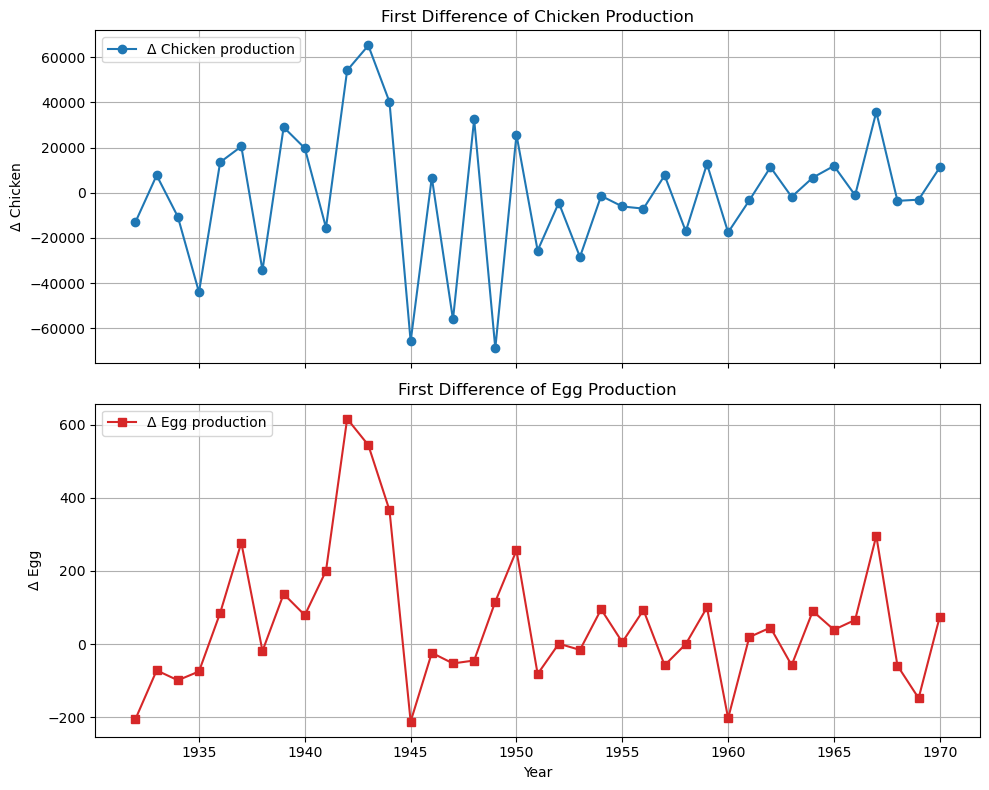

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sktime.datasets import load_chicken_egg
from sktime.distances import granger_distance

# ===================== Load Data =====================
df = load_chicken_egg()

# ===================== First Difference =====================
df_diff = df.copy()
df_diff['chicken'] = df_diff['chicken'].diff()
df_diff['egg'] = df_diff['egg'].diff()

# 去掉差分后第一行的 NaN
df_diff = df_diff.dropna().reset_index(drop=True)

# ===================== Visualization (Two Subplots) =====================
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Top: Chicken diff
axes[0].plot(
    df_diff['year'],
    df_diff['chicken'],
    color='tab:blue',
    marker='o',
    label='Δ Chicken production'
)
axes[0].set_title('First Difference of Chicken Production')
axes[0].set_ylabel('Δ Chicken')
axes[0].grid(True)
axes[0].legend(loc='upper left')

# Bottom: Egg diff
axes[1].plot(
    df_diff['year'],
    df_diff['egg'],
    color='tab:red',
    marker='s',
    label='Δ Egg production'
)
axes[1].set_title('First Difference of Egg Production')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Δ Egg')
axes[1].grid(True)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
from sktime.datasets import load_chicken_egg



df = load_chicken_egg()
df_diff = df[['chicken', 'egg']].diff().dropna()

print("egg -> chicken")
grangercausalitytests(df_diff[['chicken', 'egg']], maxlag=4)

print("chicken -> egg")
grangercausalitytests(df_diff[['egg', 'chicken']], maxlag=4)


egg -> chicken

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=10.6428 , p=0.0025  , df_denom=35, df_num=1
ssr based chi2 test:   chi2=11.5550 , p=0.0007  , df=1
likelihood ratio test: chi2=10.0889 , p=0.0015  , df=1
parameter F test:         F=10.6428 , p=0.0025  , df_denom=35, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.0100  , p=0.0128  , df_denom=32, df_num=2
ssr based chi2 test:   chi2=11.5855 , p=0.0030  , df=2
likelihood ratio test: chi2=10.0791 , p=0.0065  , df=2
parameter F test:         F=5.0100  , p=0.0128  , df_denom=32, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4135  , p=0.0304  , df_denom=29, df_num=3
ssr based chi2 test:   chi2=12.7123 , p=0.0053  , df=3
likelihood ratio test: chi2=10.8868 , p=0.0124  , df=3
parameter F test:         F=3.4135  , p=0.0304  , df_denom=29, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=5.0258  , p

{1: ({'ssr_ftest': (2.7769559770081385, 0.10455598658280617, 35.0, 1),
   'ssr_chi2test': (3.014980775037407, 0.08249843333463916, 1),
   'lrtest': (2.901346549930736, 0.08850559035961537, 1),
   'params_ftest': (2.776955977008204, 0.10455598658280178, 35.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.3723502292145022, 0.2680294424541165, 32.0, 2),
   'ssr_chi2test': (3.173559905058536, 0.20458332024250622, 2),
   'lrtest': (3.044772653142161, 0.21819059120329698, 2),
   'params_ftest': (1.37235022921468, 0.268029442454072, 32.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.7482050477294433, 0.5322432893819407, 29.0, 3),
   'ssr_chi2test': (2.7864187984406854, 0.4257405072107129, 3),
   'lrtest': (2.6838437734783724, 0.44297986172365966, 3),
   'params_ftest': (0.7482050477296873, 0.5322432893818044, 29.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0.,